In [4]:
# Importing moblienetV2 and necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import (MobileNetV2, preprocess_input, decode_predictions)
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Defining the path of the image and loading it
train_dir="plant_dataset/train"
val_dir="plant_dataset/val"
test_dir="plant_dataset/test"

In [6]:
#Loading datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
val_ds = image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
test_ds = image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')

Found 6400 files belonging to 80 classes.
Found 800 files belonging to 80 classes.
Found 800 files belonging to 80 classes.


In [7]:
#Checking class names
class_names = train_ds.class_names
print(class_names)
print(f"Number of classes: {len(class_names)}")

['Aloevera', 'Amla', 'Amruthaballi', 'Arali', 'Astma_weed', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Beans', 'Betel', 'Bhrami', 'Bringaraja', 'Caricature', 'Castor', 'Catharanthus', 'Chakte', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Ganigale', 'Ganike', 'Gasagase', 'Ginger', 'Globe Amarnath', 'Guava', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Lemon', 'Lemongrass', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Mint', 'Neem', 'Nelavembu', 'Nerale', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Parijatha', 'Pea', 'Pepper', 'Pomoegranate', 'Pumpkin', 'Raddish', 'Rose', 'Sampige', 'Sapota', 'Seethaashoka', 'Seethapala', 'Spinach1', 'Tamarind', 'Taro', 'Tecoma', 'Thumbe', 'Tomato', 'Tulsi', 'Turmeric', 'ashoka', 'camphor', 'kamakasturi', 'kepala']
Number of classes: 80


In [8]:
#Preprocessing for MobileNetV2
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))      
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))      

In [9]:
#Optimizing the model for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
#Imorting the MobileNetV2 model and training it on our dataset
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False #Freeze the base model layers for transfer learning

#Adding custom layers for our specific classification task
num_classes = len(class_names)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x) #Adding dropout for regularization
x=Dense(256, activation='relu')(x)
x=Dropout(0.3)(x)
predictions=Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

#Compiling the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Callback for early stopping
checkpoint=ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stopping=EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

Training the model

In [12]:
#Training the model
history=model.fit(train_ds,
validation_data=val_ds,
epochs=10,
callbacks=[checkpoint, early_stopping])

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1467 - loss: 3.8973
Epoch 1: val_accuracy improved from -inf to 0.53000, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.1474 - loss: 3.8933 - val_accuracy: 0.5300 - val_loss: 1.8698
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5653 - loss: 1.6527
Epoch 2: val_accuracy improved from 0.53000 to 0.67625, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.5655 - loss: 1.6519 - val_accuracy: 0.6762 - val_loss: 1.2425
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6857 - loss: 1.1052
Epoch 3: val_accuracy improved from 0.67625 to 0.71875, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.6857 - loss: 1.1050 - val_accuracy: 0.7188 - val_loss: 1.0006
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7561 - loss: 0.8695
Epoch 4: val_accuracy improved from 0.71875 to 0.77250, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.7561 - loss: 0.8693 - val_accuracy: 0.7725 - val_loss: 0.8324
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7908 - loss: 0.7186
Epoch 5: val_accuracy improved from 0.77250 to 0.81125, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.7909 - loss: 0.7184 - val_accuracy: 0.8112 - val_loss: 0.7272
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8196 - loss: 0.6040
Epoch 6: val_accuracy did not improve from 0.81125
200/200 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.8196 - loss: 0.6040 - val_accuracy: 0.8050 - val_loss: 0.6794
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8320 - loss: 0.5521
Epoch 7: val_accuracy improved from 0.81125 to 0.82500, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.8320 - loss: 0.5520 - val_accuracy: 0.8250 - val_loss: 0.6533
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8613 - loss: 0.4668
Epoch 8: val_accuracy improved from 0.82500 to 0.83375, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.8613 - loss: 0.4668 - val_accuracy: 0.8338 - val_loss: 0.6056
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8582 - loss: 0.4596
Epoch 9: val_accuracy improved from 0.83375 to 0.83750, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.8583 - loss: 0.4595 - val_accuracy: 0.8375 - val_loss: 0.6012
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8740 - loss: 0.4030
Epoch 10: val_accuracy did not improve from 0.83750
200/200 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.8741 - loss: 0.4030 - val_accuracy: 0.8325 - val_loss: 0.5816


 Fine Tuning

In [13]:
# Unfreeze the base model layers for fine-tuning (only top 40 layers)
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

#Recompile the model with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])

 #Add callbacks for safety and performance
checkpoint_finetune=tf.keras.callbacks.ModelCheckpoint(
    'best_model_finetune.keras',
     monitor='val_accuracy', 
     save_best_only=True, 
      verbose=1)

early_stop_finetune=tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True)

#Fine-tune for a few epochs
history_finetune=model.fit(train_ds,
 validation_data=val_ds,
 epochs=10,
 callbacks=[checkpoint_finetune, early_stop_finetune])

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5785 - loss: 1.5761
Epoch 1: val_accuracy improved from -inf to 0.83500, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.5788 - loss: 1.5748 - val_accuracy: 0.8350 - val_loss: 0.6002
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7353 - loss: 0.9171
Epoch 2: val_accuracy improved from 0.83500 to 0.84125, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.7354 - loss: 0.9167 - val_accuracy: 0.8413 - val_loss: 0.5702
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7911 - loss: 0.7022
Epoch 3: val_accuracy improved from 0.84125 to 0.84250, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.7912 - loss: 0.7021 - val_accuracy: 0.8425 - val_loss: 0.5472
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8342 - loss: 0.5583
Epoch 4: val_accuracy improved from 0.84250 to 0.84500, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.8342 - loss: 0.5582 - val_accuracy: 0.8450 - val_loss: 0.5310
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8527 - loss: 0.5116
Epoch 5: val_accuracy improved from 0.84500 to 0.84625, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.8527 - loss: 0.5114 - val_accuracy: 0.8462 - val_loss: 0.5210
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8650 - loss: 0.4540
Epoch 6: val_accuracy did not improve from 0.84625
200/200 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.8650 - loss: 0.4540 - val_accuracy: 0.8425 - val_loss: 0.5094
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8710 - loss: 0.4276
Epoch 7: val_accuracy improved from 0.84625 to 0.85375, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.8710 - loss: 0.4275 - val_accuracy: 0.8537 - val_loss: 0.5018
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9006 - loss: 0.3644
Epoch 8: val_accuracy did not improve from 0.85375
200/200 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.9006 - loss: 0.3643 - val_accuracy: 0.8512 - val_loss: 0.4872
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8958 - loss: 0.3407
Epoch 9: val_accuracy improved from 0.85375 to 0.85750, saving model to best_model_finetune.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.8958 - loss: 0.3406 - val_accuracy: 0.8575 - val_loss: 0.4708
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9037 - loss: 0.3200
Epoch 10: val_accuracy did not improve from 0.85750
200/200 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9038 - loss: 0.3199 - val_accuracy: 0.8575 - val_loss: 0.4637


Saving the model

In [14]:
model.save('final_mobilenet_model.keras')

In [15]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8577 - loss: 0.4541
Validation Accuracy: 0.8575
Validation Loss: 0.4708


Prediction on test dataset

In [16]:
#Prediction on test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9021 - loss: 0.3817
Test Accuracy: 0.8913
Test Loss: 0.4264


Prediction

In [27]:
#prediction on a single image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#Use the class names captured before dataset preprocessing
print(class_names)

#loads and preprocess the uploaded image
img_path = 'OT-S-001.jpg'  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = preprocess_input(img_array)

#predicting the class of the image
pred = model.predict(img_array, verbose=0)
predicted_class = np.argmax(pred, axis=1)[0]
#print only top 5 classes with probabilities
top_5_indices = np.argsort(pred[0])[-5:][::-1]
print(f"Top 5 Predictions:")
for i, idx in enumerate(top_5_indices):
    print(f"{i+1}. {class_names[idx]}: {pred[0][idx]:.4f}")
plant_name = class_names[predicted_class]
print(f"Predicted Plant: {plant_name}")

['Aloevera', 'Amla', 'Amruthaballi', 'Arali', 'Astma_weed', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Beans', 'Betel', 'Bhrami', 'Bringaraja', 'Caricature', 'Castor', 'Catharanthus', 'Chakte', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Ganigale', 'Ganike', 'Gasagase', 'Ginger', 'Globe Amarnath', 'Guava', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Lemon', 'Lemongrass', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Mint', 'Neem', 'Nelavembu', 'Nerale', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Parijatha', 'Pea', 'Pepper', 'Pomoegranate', 'Pumpkin', 'Raddish', 'Rose', 'Sampige', 'Sapota', 'Seethaashoka', 'Seethapala', 'Spinach1', 'Tamarind', 'Taro', 'Tecoma', 'Thumbe', 'Tomato', 'Tulsi', 'Turmeric', 'ashoka', 'camphor', 'kamakasturi', 'kepala']
Top 5 Predictions:
1. Hibiscus: 0.7649
2. Caricature:

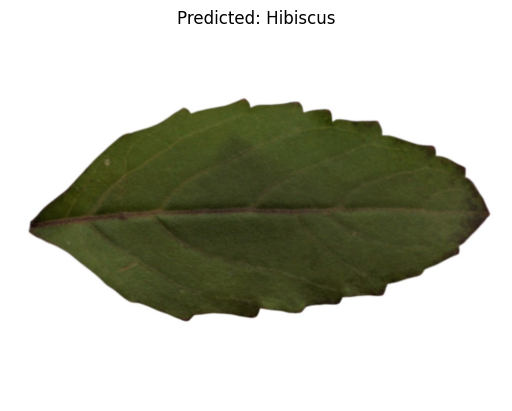

In [28]:
#Show the image and prediction
plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {plant_name}")
plt.axis('off')
plt.show()

In [29]:
#prediction index into json
import json
with open('class_indices.json', 'w') as f:
    json.dump({idx: name for idx, name in enumerate(class_names)}, f, indent=2)